# 3D Visualization of cooling Kob-Andersen Lennard-Jones mixture
Requires the 'k3d' and  'ipywidgets' packages

In [1]:
import sys
sys.path

['/usr/lib/python313.zip',
 '/usr/lib/python3.13',
 '/usr/lib/python3.13/lib-dynload',
 '',
 '/net/debye/jklust/gamdpy/venv/lib/python3.13/site-packages',
 '/net/debye/jklust/gamdpy',
 '/net/debye/jklust/K3D-jupyter',
 '/net/debye/jklust/.local/lib/python3.13/site-packages',
 '/usr/local/lib/python3.13/dist-packages',
 '/usr/lib/python3/dist-packages']

In [2]:
import numpy as np
import gamdpy as gp
import numba

import matplotlib.pyplot as plt
#%matplotlib inline
#%matplotlib notebook
#%matplotlib widget


## Generate configuration with a FCC lattice

In [3]:
configuration = gp.Configuration(D=3)
configuration.make_lattice(gp.unit_cells.FCC, cells=[8, 8, 8], rho=0.973)
configuration['m'] = 1.0
configuration.randomize_velocities(temperature=0.7)

#c1 = gp.make_configuration_fcc(nx=6, ny=6, nz=6, rho=0.60) 
#c1.ptype[::5] = 1 # 4:1 mixture
#c1.randomize_velocities(temperature=0.7)
print(configuration)
#print(f'Number of particles: {configuration.N}; Density: {configuration.N/np.prod(configuration.simbox.lengths):.3f}; B fraction: {np.mean(configuration.ptype==1):.3f}')

2048 particles in 3 dimensions. Number density (atomic): 0.973. Single component. 
Current scalar data per particle:
U,    0.000	Potential energy.
W,    0.000	Virial.
K,    0.000	Kinetic energy.
m,    1.000	Particle mass.


## Setup Lennard-Jones pair potential

In [4]:
#pairfunc = gp.apply_shifted_force_cutoff(rp.LJ_12_6_sigma_epsilon)
#sig = [[1.00, 0.80],
#       [0.80, 0.88]]
#eps = [[1.00, 1.50],
#       [1.50, 0.50]]
#cut = np.array(sig)*2.5
#pairpot = gp.PairPotential2(pairfunc, params=[sig, eps, cut], max_num_nbs=1000)
#pairpot.plot(names=['A', 'B'], xlim=(0.6, 2.6), ylim=(-1.5, 4))

# Setup pair potential: Single component 12-6 Lennard-Jones
pair_func = gp.apply_shifted_potential_cutoff(gp.LJ_12_6_sigma_epsilon)
sig, eps, cut = 1.0, 1.0, 2.5
pair_pot = gp.PairPotential(pair_func, params=[sig, eps, cut], max_num_nbs=1000)

## Setup integrator

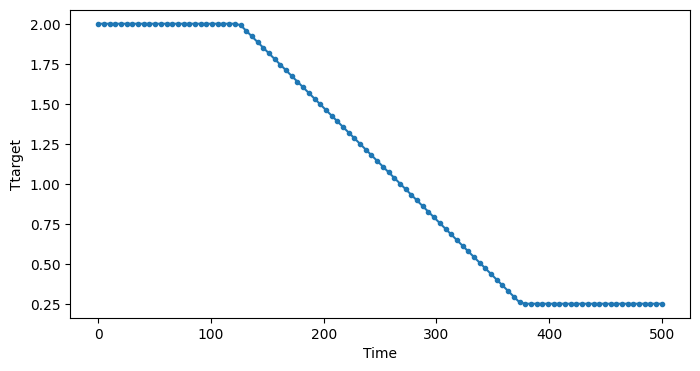

In [5]:
dt = 0.005              # Duration of timestep 
num_blocks = 100        # Do simulation in this many 'blocks'
steps_per_block = 1000  # ... each of this many timesteps
running_time = dt*num_blocks*steps_per_block

Ttarget_function = gp.make_function_ramp(value0=2.00, x0=running_time*(1/4), 
                                         value1=0.25, x1=running_time*(3/4))
#integrator = gp.integrators.NVT(Ttarget_function, tau=0.2, dt=dt)

plt.figure(figsize=(8,4))
t = np.linspace(0,running_time,num_blocks)
plt.plot(t, numba.vectorize(Ttarget_function)(t), '.-')
plt.xlabel('Time')
plt.ylabel('Ttarget')
plt.show()

# Setup integrator: NVT
integrator = gp.integrators.NVT(Ttarget_function, tau=0.2, dt=0.005)

# Setup runtime actions, i.e., actions performed during simulation of timeblocks
runtime_actions = [gp.TrajectorySaver(),
                   gp.ScalarSaver(100),
                   gp.RestartSaver(),
                   gp.MomentumReset(100)]

## Setup simulation

In [6]:
#sim = gp.Simulation(c1, pairpot, integrator,
#                    num_timeblocks=num_blocks, steps_per_timeblock=steps_per_block,
#                    steps_between_momentum_reset=100,
#                    storage='memory')

# Setup Simulation. 
sim = gp.Simulation(configuration, [pair_pot], integrator, runtime_actions,
                    num_timeblocks=num_blocks, steps_per_timeblock=steps_per_block,
                    storage='memory')

## Run simulation with 3D visualization

In [7]:
from gamdpy.visualization import k3d_Visualization

viz = k3d_Visualization(sim)
viz.display()
for block in sim.run_timeblocks():
    viz.update(block, choice=2)

viz.display_player()
print('\n', sim.summary())

Output()


 Particles : 2048 
Steps : 100 * 1000 = 100_000 
Total run time  (incl. time spent between timeblocks): 6.51 s ( TPS: 1.54e+04 )
Simulation time (excl. time spent between timeblocks): 4.54 s ( TPS: 2.20e+04 )



In [8]:
gp.tools.print_h5_structure(sim.output)

initial_configuration/ (Group)
    ptype  (Dataset, shape=(2048,), dtype=int32)
    r_im  (Dataset, shape=(2048, 3), dtype=int32)
    scalars  (Dataset, shape=(2048, 4), dtype=float32)
    topology/ (Group)
        angles  (Dataset, shape=(0,), dtype=int32)
        bonds  (Dataset, shape=(0,), dtype=int32)
        dihedrals  (Dataset, shape=(0,), dtype=int32)
        molecules/ (Group)
    vectors  (Dataset, shape=(3, 2048, 3), dtype=float32)
restarts/ (Group)
    restart0000/ (Group)
        ptype  (Dataset, shape=(2048,), dtype=int32)
        r_im  (Dataset, shape=(2048, 3), dtype=int32)
        scalars  (Dataset, shape=(2048, 4), dtype=float32)
        topology/ (Group)
            angles  (Dataset, shape=(0,), dtype=int32)
            bonds  (Dataset, shape=(0,), dtype=int32)
            dihedrals  (Dataset, shape=(0,), dtype=int32)
            molecules/ (Group)
        vectors  (Dataset, shape=(3, 2048, 3), dtype=float32)
    restart0001/ (Group)
        ptype  (Dataset, shape=(2

In [9]:
gp.tools.print_h5_attributes(sim.output)

Attributes at /:
    - dt: 0.005
    - script_content: ...
    - script_name: ...
Attributes at /initial_configuration/:
    - simbox_data: [12.815602 12.815602 12.815602]
    - simbox_name: Orthorhombic
Attributes at /initial_configuration/scalars:
    - scalar_columns: ['U' 'W' 'K' 'm']
Attributes at /initial_configuration/topology/molecules/:
    - names: []
Attributes at /initial_configuration/vectors:
    - vector_columns: ['r' 'v' 'f']
Attributes at /restarts/:
    - timeblocks_between_restarts: 1
Attributes at /restarts/restart0000/:
    - simbox_data: [12.815602 12.815602 12.815602]
    - simbox_name: Orthorhombic
Attributes at /restarts/restart0000/scalars:
    - scalar_columns: ['U' 'W' 'K' 'm']
Attributes at /restarts/restart0000/topology/molecules/:
    - names: []
Attributes at /restarts/restart0000/vectors:
    - vector_columns: ['r' 'v' 'f']
Attributes at /restarts/restart0001/:
    - simbox_data: [12.815602 12.815602 12.815602]
    - simbox_name: Orthorhombic
Attributes

In [11]:
output=sim.output
output['scalars/scalars'][1]
output['/restarts/restart0000/'].attrs['simbox_data']
block=1
restart_num = f"restart{block:04d}"
print(output[f'/restarts/{restart_num}/vectors/'])
print(output[f'/restarts/{restart_num}/scalars/'])

<HDF5 dataset "vectors": shape (3, 2048, 3), type "<f4">
<HDF5 dataset "scalars": shape (2048, 4), type "<f4">
